# Week 2: Html parsing funciton

Goal: Parse the html_table of Week 1 into a true tabular structure DataFrame, with a focus on colspan and rowspan.  

Experiment 1: simplest version  
Experiment 2: support colspan   
Experiment 3: support colspan + rowspan


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# confirm the path
import os

base_path = "/content/drive/MyDrive/cv project"
os.listdir(base_path)

['week2_html parsing function.ipynb',
 'hierarchical_tables_v1.zip',
 'hierarchical_tables_v1',
 'week1_eda+teds.html',
 'week1_eda+teds.ipynb']

In [ ]:
# define base path

base_path = "/content/drive/MyDrive/cv project"
data_path = os.path.join(base_path, "hierarchical_tables_v1", "data", "processed")

jsonl_path = os.path.join(data_path, "hard_examples_subset.jsonl")
image_dir = os.path.join(data_path, "images")

print("JSONL exists:", os.path.exists(jsonl_path))
print("Image dir exists:", os.path.exists(image_dir))

JSONL exists: True
Image dir exists: True


In [ ]:
# read jsonl
import json

records = []

with open(jsonl_path, "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

print("Total records:", len(records))
print(records[0].keys())

Total records: 32670
dict_keys(['html_table', 'imgid'])


In [ ]:
# check sample
html = records[0]["html_table"]

print(html[:1000])

<table>
 <tr>
  <td>
  </td>
  <td colspan="3">
   Year Ended
  </td>
 </tr>
 <tr>
  <td>
  </td>
  <td>
   December 31, 2017
  </td>
  <td>
   December 31, 2016
  </td>
  <td>
   December 31, 2015
  </td>
 </tr>
 <tr>
  <td>
   Development projects:
  </td>
  <td>
  </td>
  <td>
  </td>
  <td>
  </td>
 </tr>
 <tr>
  <td>
   Triple-net
  </td>
  <td>
   $283,472
  </td>
  <td>
   $46,094
  </td>
  <td>
   $104,844
  </td>
 </tr>
 <tr>
  <td>
   Seniors housing operating
  </td>
  <td>
   3,634
  </td>
  <td>
   18,979
  </td>
  <td>
   19,869
  </td>
 </tr>
 <tr>
  <td>
   Outpatient medical
  </td>
  <td>
   63,036
  </td>
  <td>
   108,001
  </td>
  <td>
   16,592
  </td>
 </tr>
 <tr>
  <td>
   Total development projects
  </td>
  <td>
   350,142
  </td>
  <td>
   173,074
  </td>
  <td>
   141,305
  </td>
 </tr>
 <tr>
  <td>
   Expansion projects
  </td>
  <td>
   10,336
  </td>
  <td>
   11,363
  </td>
  <td>
   38,808
  </td>
 </tr>
 <tr>
  <td>
   Total construction in progress co

# Filter out the data with both rowspan and colspan

In [ ]:
csv_path = os.path.join(base_path, "df_combined.csv") #labeled dataset from week1 output

df_combined = pd.read_csv(csv_path)

print(df_combined.shape)
df_combined.head()

(32670, 21)


,num_rows,num_cells,max_colspan,max_rowspan,has_colspan,has_rowspan,is_complex,hard_score,imgid,img_file,...,height,aspect_ratio,width_bin,height_bin,aspect_ratio_bin,blur_score,blur_bin,contrast_score,contrast_bin,image_type
0,9,34,3,1,True,False,True,12.5,fintabnet_000001,fintabnet_000001.png,...,464.0,3.127155,"(1200, 1500]","(300, 600]","(3, 5]",3678.917551,"(2000, 4000]",43.968108,"(40, 50]",wide_table
1,40,158,3,1,True,False,True,28.0,fintabnet_000004,fintabnet_000004.png,...,1826.0,0.795181,"(1200, 1500]","(1600, 2000]","(0, 1]",2894.365766,"(2000, 4000]",38.080415,"(20, 40]",tall_table
2,6,55,2,2,True,True,True,11.0,fintabnet_000006,fintabnet_000006.png,...,366.0,4.144809,"(1500, 2000]","(300, 600]","(3, 5]",6247.870952,"(6000, 8000]",55.573495,"(50, 60]",wide_table
3,7,26,3,1,True,False,True,11.5,fintabnet_000007,fintabnet_000007.png,...,330.0,4.015152,"(1200, 1500]","(300, 600]","(3, 5]",4598.369386,"(4000, 6000]",51.369766,"(50, 60]",wide_table
4,12,46,2,2,True,True,True,14.0,fintabnet_000008,fintabnet_000008.png,...,527.0,2.755218,"(1200, 1500]","(300, 600]","(2, 3]",7751.798653,"(6000, 8000]",38.023786,"(20, 40]",low_contrast


In [ ]:
df_combined.columns

Index(['num_rows', 'num_cells', 'max_colspan', 'max_rowspan', 'has_colspan',
       'has_rowspan', 'is_complex', 'hard_score', 'imgid', 'img_file', 'width',
       'height', 'aspect_ratio', 'width_bin', 'height_bin', 'aspect_ratio_bin',
       'blur_score', 'blur_bin', 'contrast_score', 'contrast_bin',
       'image_type'],
      dtype='object')

In [ ]:
len(df_combined.columns)

21

In [ ]:
# total complex samples
complex_samples = df_combined[
    (df_combined["max_colspan"] > 1) &
    (df_combined["max_rowspan"] > 1)
].copy()

print("Complex samples:", len(complex_samples))
complex_samples[["imgid", "max_colspan", "max_rowspan"]].head()

Complex samples: 1510


,imgid,max_colspan,max_rowspan
2,fintabnet_000006,2,2
4,fintabnet_000008,2,2
7,fintabnet_000012,2,2
14,fintabnet_000026,2,2
15,fintabnet_000028,2,2


## Merge html format to complex_samples, base on imgid

In [ ]:
imgid_to_html = {r["imgid"]: r["html_table"] for r in records}

In [ ]:
complex_samples["html_table"] = complex_samples["imgid"].map(imgid_to_html)

In [ ]:
complex_samples[["imgid", "html_table"]].head()

,imgid,html_table
2,fintabnet_000006,<table>\n <tr>\n <td>\n </td>\n <td colspan...
4,fintabnet_000008,<table>\n <tr>\n <td>\n </td>\n <td colspan...
7,fintabnet_000012,<table>\n <tr>\n <td>\n </td>\n <td colspan...
14,fintabnet_000026,<table>\n <tr>\n <td>\n </td>\n <td colspan...
15,fintabnet_000028,<table>\n <tr>\n <td>\n </td>\n <td colspan...


In [ ]:
# check columns/features
complex_samples.columns

Index(['num_rows', 'num_cells', 'max_colspan', 'max_rowspan', 'has_colspan',
       'has_rowspan', 'is_complex', 'hard_score', 'imgid', 'img_file', 'width',
       'height', 'aspect_ratio', 'width_bin', 'height_bin', 'aspect_ratio_bin',
       'blur_score', 'blur_bin', 'contrast_score', 'contrast_bin',
       'image_type', 'html_table'],
      dtype='object')

In [ ]:
len(complex_samples.columns)

22

# Experiment 1: simplest version  
only extract the cell text of each row, but not deal with colspan / rowspan.  
The goal is to understand how HTML is transformed into a two-dimensional table.  

HTML table  
↓  
transform each **tr** into a row  
↓  
transform each **td/th** into a cell

In [ ]:
from bs4 import BeautifulSoup
import pandas as pd

def parse_simple_html_table(html):
    soup = BeautifulSoup(html, "html.parser")
    table = soup.find("table")

    rows = []

    for tr in table.find_all("tr"):
        row = []
        cells = tr.find_all(["td", "th"])

        for cell in cells:
            text = cell.get_text(strip=True)
            row.append(text)

        rows.append(row)

    return rows


# # show parsed result
# simple_rows = parse_simple_html_table(records[0]["html_table"])
# print("Parsed rows:")
# simple_rows[:3]

Parsed rows:


[['', 'Year Ended'],
 ['', 'December 31, 2017', 'December 31, 2016', 'December 31, 2015'],
 ['Development projects:', '', '', '']]

In [ ]:
# Extract 1 data from complex_samples
sample = complex_samples.iloc[0]

html = sample["html_table"]
imgid = sample["imgid"]

print("Sample imgid:", imgid)

Sample imgid: fintabnet_000006


In [ ]:
# parse structure from html
simple_rows = parse_simple_html_table(html)

print("imgid:", imgid)
print("max_colspan:", sample["max_colspan"])
print("max_rowspan:", sample["max_rowspan"])

print("\nParsed rows:")
for r in simple_rows[:5]:
    print(r)

imgid: fintabnet_000006
max_colspan: 2
max_rowspan: 2

Parsed rows:
['', 'Year Ended', 'One Year Change', 'Year Ended December 31, 2017', 'One Year Change', 'Two Year Change']
['', 'December 31, 2015', 'December 31, 2016', '$', '%', '$', '%', '$', '%']
['NOI', '$1,175,806', '$1,208,860', '$33,054', '3%', '$967,084', '$(241,776)', '-20%', '$(208,722)', '-18%']
['Non-cash NOI attributable to same store properties(1)', '(48,890)', '(38,899)', '9,991', '-20%', '(28,602)', '10,297', '-26%', '20,288', '-41%']
['NOI attributable to non same store properties(2)', '(498,131)', '(574,049)', '(75,918)', '15%', '(333,279)', '240,770', '-42%', '164,852', '-33%']


Parsed df use simple vision


,0,1,2,3,4,5,6,7,8,9
0,,Year Ended,One Year Change,"Year Ended December 31, 2017",One Year Change,Two Year Change,None,None,None,None
1,,"December 31, 2015","December 31, 2016",$,%,$,%,$,%,None
2,NOI,"$1,175,806","$1,208,860","$33,054",3%,"$967,084","$(241,776)",-20%,"$(208,722)",-18%
3,Non-cash NOI attributable to same store proper...,"(48,890)","(38,899)","9,991",-20%,"(28,602)","10,297",-26%,"20,288",-41%
4,NOI attributable to non same store properties(2),"(498,131)","(574,049)","(75,918)",15%,"(333,279)","240,770",-42%,"164,852",-33%
5,SSNOI(1),"$628,785","$595,912","$(32,873)",-5%,"$605,203","$9,291",2%,"$(23,582)",-4%


Image path: /content/drive/MyDrive/cv project/hierarchical_tables_v1/data/processed/images/fintabnet_000006.png


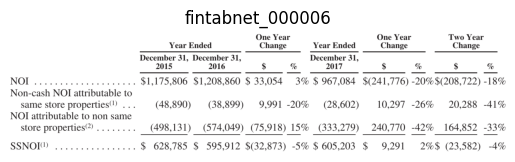

In [ ]:
# parse html into dataframe
df_simple = pd.DataFrame(simple_rows)
print("Parsed df use simple vision")
display(df_simple)


# compare to original image
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_DIR = "/content/drive/MyDrive/cv project/hierarchical_tables_v1/data/processed/images"

sample = complex_samples.iloc[0]
imgid = sample["imgid"]
img_path = os.path.join(IMAGE_DIR, imgid + ".png")

print("Image path:", img_path)
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.title(imgid)
plt.show()

The simple parser successfully extracts raw text content but fails to preserve structural information, especially for tables with multi-level headers and merged cells, resulting in column misalignment and loss of semantic relationships.  
This aligns with EDA findings that tables with high colspan/rowspan are more complex and harder to parse correctly.   
**issue**  
```
\<td colspan="2"\>Year Ended\</td>
should be:
Year Ended | Year Ended  
```



The table has some rows with only one column, while some rows (with merged cells) have >2 columns (colspan). The current code only reads the cell once, resulting in the compressed data across rows and columns not being expanded. Pandas will automatically fill in with 'none' later.  



# Experiment 2: support colspan

In [ ]:
def parse_table_with_colspan(html):
    soup = BeautifulSoup(html, "html.parser")
    table = soup.find("table")

    rows = []

    for tr in table.find_all("tr"):
        row = []
        cells = tr.find_all(["td", "th"])

        for cell in cells:
            text = cell.get_text(strip=True)
            colspan = int(cell.get("colspan", 1))

            for _ in range(colspan):
                row.append(text)

        rows.append(row)

    return rows

# rows_colspan = parse_table_with_colspan(records[0]["html_table"])
# df_colspan = pd.DataFrame(rows_colspan)
# df_colspan

imgid: fintabnet_000006
max_colspan: 2
max_rowspan: 2
Parsed DataFrame with colspan support:


,0,1,2,3,4,5,6,7,8,9
0,,Year Ended,Year Ended,One Year Change,One Year Change,"Year Ended December 31, 2017",One Year Change,One Year Change,Two Year Change,Two Year Change
1,,"December 31, 2015","December 31, 2016",$,%,$,%,$,%,None
2,NOI,"$1,175,806","$1,208,860","$33,054",3%,"$967,084","$(241,776)",-20%,"$(208,722)",-18%
3,Non-cash NOI attributable to same store proper...,"(48,890)","(38,899)","9,991",-20%,"(28,602)","10,297",-26%,"20,288",-41%
4,NOI attributable to non same store properties(2),"(498,131)","(574,049)","(75,918)",15%,"(333,279)","240,770",-42%,"164,852",-33%
5,SSNOI(1),"$628,785","$595,912","$(32,873)",-5%,"$605,203","$9,291",2%,"$(23,582)",-4%


Original image:


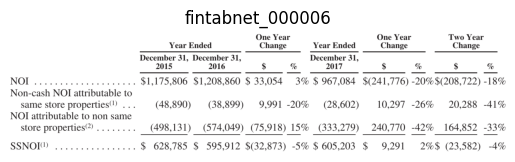

In [ ]:
# Use the same complex sample
sample = complex_samples.iloc[0]

html = sample["html_table"]
imgid = sample["imgid"]

print("imgid:", imgid)
print("max_colspan:", sample["max_colspan"])
print("max_rowspan:", sample["max_rowspan"])

# Parse HTML into df
rows_colspan = parse_table_with_colspan(html)
df_colspan = pd.DataFrame(rows_colspan)

print("Parsed DataFrame with colspan support:")
display(df_colspan)

# show original image
IMAGE_DIR = "/content/drive/MyDrive/cv project/hierarchical_tables_v1/data/processed/images"

img_path = os.path.join(IMAGE_DIR, imgid + ".png")

print("Original image:")
plt.imshow(Image.open(img_path))
plt.axis("off")
plt.title(imgid)
plt.show()

 **issue**  
In[0,4], header elements that should appear on separate rows are incorrectly merged into the same row.  
For example, **“Year Ended”** and **“December 31, 2017”** are combined into a single cell, whereas in the original table they belong to two different header rows.  This also indirectly led to the last column of the first row being "none".  

**cause**  
the current parser processes the table row by row (\<tr>) and only handles horizontal expansion (colspan), but does not enforce consistent column alignment across rows.  
In the original HTML, the header is structured as:
```
<tr>
  <th colspan="...">Year Ended</th>
</tr>
<tr>
  <th>December 31, 2017</th>
</tr>
```
This represents a multi-level header, where the first row defines a group (“Year Ended”),
the second row provides the specific column label (“December 31, 2017”).

However, because different rows have different numbers of columns after colspan expansion, the parser produces uneven row lengths. When converting to a DataFrame, these rows are implicitly aligned or compressed, leading to the incorrect merge of rowspan

**next step**  
- enforce consistent row lengths (row normalization)  
- preserve hierarchical relationships across rows (eventually requiring rowspan handling).






# Experiment 3: support colspan + rowspan

In [ ]:
# def parse_table_with_span(html):
#     soup = BeautifulSoup(html, "html.parser")
#     table = soup.find("table")

#     grid = []
#     rowspan_map = {}

#     for row_idx, tr in enumerate(table.find_all("tr")):
#         row = []
#         col_idx = 0

#         # Fill cells carried over from previous rowspans
#         while (row_idx, col_idx) in rowspan_map:
#             value, remaining = rowspan_map[(row_idx, col_idx)]
#             row.append(value)

#             if remaining > 1:
#                 rowspan_map[(row_idx + 1, col_idx)] = (value, remaining - 1)

#             col_idx += 1

#         for cell in tr.find_all(["td", "th"]):
#             # Skip occupied positions caused by rowspan
#             while (row_idx, col_idx) in rowspan_map:
#                 value, remaining = rowspan_map[(row_idx, col_idx)]
#                 row.append(value)

#                 if remaining > 1:
#                     rowspan_map[(row_idx + 1, col_idx)] = (value, remaining - 1)

#                 col_idx += 1

#             text = cell.get_text(strip=True)
#             colspan = int(cell.get("colspan", 1))
#             rowspan = int(cell.get("rowspan", 1))

#             for i in range(colspan):
#                 row.append(text)

#                 if rowspan > 1:
#                     rowspan_map[(row_idx + 1, col_idx + i)] = (text, rowspan - 1)

#             col_idx += colspan

#         grid.append(row)

#     return grid

In [ ]:
from bs4 import BeautifulSoup
import pandas as pd

def parse_table_with_span(html):
    soup = BeautifulSoup(html, "html.parser")
    table = soup.find("table")

    grid = []
    rowspan_map = {}

    for row_idx, tr in enumerate(table.find_all("tr")):
        row = []
        col_idx = 0

        for cell in tr.find_all(["td", "th"]):

            # Fill positions already occupied by previous rowspan cells
            while (row_idx, col_idx) in rowspan_map:
                value, remaining = rowspan_map.pop((row_idx, col_idx))
                row.append(value)

                if remaining > 1:
                    rowspan_map[(row_idx + 1, col_idx)] = (value, remaining - 1)

                col_idx += 1

            text = cell.get_text(strip=True)
            colspan = int(cell.get("colspan", 1))
            rowspan = int(cell.get("rowspan", 1))

            # Expand colspan horizontally
            for offset in range(colspan):
                row.append(text)

                # Carry value down if rowspan exists
                if rowspan > 1:
                    rowspan_map[(row_idx + 1, col_idx + offset)] = (text, rowspan - 1)

            col_idx += colspan

        # Fill remaining rowspan cells after the last cell in this row
        while (row_idx, col_idx) in rowspan_map:
            value, remaining = rowspan_map.pop((row_idx, col_idx))
            row.append(value)

            if remaining > 1:
                rowspan_map[(row_idx + 1, col_idx)] = (value, remaining - 1)

            col_idx += 1

        grid.append(row)

    return grid


def normalize_rows(rows, fill_value=""):
    max_len = max(len(row) for row in rows)
    return [row + [fill_value] * (max_len - len(row)) for row in rows]


def html_to_dataframe_with_span(html):
    rows = parse_table_with_span(html)
    rows = normalize_rows(rows)
    return pd.DataFrame(rows)

In [ ]:
sample = complex_samples.iloc[0]

html = sample["html_table"]
imgid = sample["imgid"]

print("imgid:", imgid)
print("max_colspan:", sample["max_colspan"])
print("max_rowspan:", sample["max_rowspan"])

df_span = html_to_dataframe_with_span(html)

display(df_span)

imgid: fintabnet_000006
max_colspan: 2
max_rowspan: 2


,0,1,2,3,4,5,6,7,8,9
0,,Year Ended,Year Ended,One Year Change,One Year Change,"Year Ended December 31, 2017",One Year Change,One Year Change,Two Year Change,Two Year Change
1,,"December 31, 2015","December 31, 2016",$,%,"Year Ended December 31, 2017",$,%,$,%
2,NOI,"$1,175,806","$1,208,860","$33,054",3%,"$967,084","$(241,776)",-20%,"$(208,722)",-18%
3,Non-cash NOI attributable to same store proper...,"(48,890)","(38,899)","9,991",-20%,"(28,602)","10,297",-26%,"20,288",-41%
4,NOI attributable to non same store properties(2),"(498,131)","(574,049)","(75,918)",15%,"(333,279)","240,770",-42%,"164,852",-33%
5,SSNOI(1),"$628,785","$595,912","$(32,873)",-5%,"$605,203","$9,291",2%,"$(23,582)",-4%


In [ ]:
html

'<table>\n <tr>\n  <td>\n  </td>\n  <td colspan="2">\n   Year Ended\n  </td>\n  <td colspan="2">\n   One Year Change\n  </td>\n  <td rowspan="2">\n   Year Ended December 31, 2017\n  </td>\n  <td colspan="2">\n   One Year Change\n  </td>\n  <td colspan="2">\n   Two Year Change\n  </td>\n </tr>\n <tr>\n  <td>\n  </td>\n  <td>\n   December 31, 2015\n  </td>\n  <td>\n   December 31, 2016\n  </td>\n  <td>\n   $\n  </td>\n  <td>\n   %\n  </td>\n  <td>\n   $\n  </td>\n  <td>\n   %\n  </td>\n  <td>\n   $\n  </td>\n  <td>\n   %\n  </td>\n </tr>\n <tr>\n  <td>\n   NOI\n  </td>\n  <td>\n   $1,175,806\n  </td>\n  <td>\n   $1,208,860\n  </td>\n  <td>\n   $33,054\n  </td>\n  <td>\n   3%\n  </td>\n  <td>\n   $967,084\n  </td>\n  <td>\n   $(241,776)\n  </td>\n  <td>\n   -20%\n  </td>\n  <td>\n   $(208,722)\n  </td>\n  <td>\n   -18%\n  </td>\n </tr>\n <tr>\n  <td>\n   Non-cash NOI attributable to same store properties\n   <sup>\n    (1)\n   </sup>\n  </td>\n  <td>\n   (48,890)\n  </td>\n  <td>\n   (38,

The colspan + rowspan parser fixes the missing value issue in the second header row. Also correctly handle the situation when rowspan="2", extended the cell to the next row.  

Data in[0,5], which is "the “Year Ended December 31, 2017” still remain in the same row is not a problem related to the expansion logic of colspan/rowspan, but a text granularity issue of HTML ground truth.

the original HTML is written below, which means the combined text already exists in the source HTML:  
```
<td rowspan="2">
  Year Ended December 31, 2017
</td>
```  

Therefore, the parser is correctly preserving the HTML structure, and further splitting this text into two header levels would require an additional semantic post-processing rule rather than rowspan parsing logic.

### test 1 sample

imgid: fintabnet_000008
max_colspan: 2
max_rowspan: 2

Parsed table:


,0,1,2,3
0,,Sales Price,Sales Price,Dividends Paid Per Share
1,,High,Low,Dividends Paid Per Share
2,2017,,,
3,First Quarter,$71.17,$64.63,$0.87
4,Second Quarter,78.17,68.66,0.87
5,Third Quarter,75.91,69.77,0.87
6,Fourth Quarter,70.87,63.06,0.87
7,2016,,,
8,First Quarter,$70.45,$52.80,$0.86
9,Second Quarter,76.24,66.55,0.86



Original image:


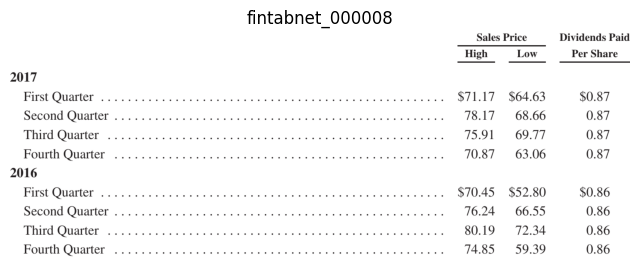

In [ ]:
sample = complex_samples.iloc[1]

html = sample["html_table"]
imgid = sample["imgid"]

print("imgid:", imgid)
print("max_colspan:", sample["max_colspan"])
print("max_rowspan:", sample["max_rowspan"])

# parse html
rows = parse_table_with_span(html)
rows = normalize_rows(rows)

df_parsed = pd.DataFrame(rows)
print("\nParsed table:")
display(df_parsed)

# show original image
IMAGE_DIR = "/content/drive/MyDrive/cv project/hierarchical_tables_v1/data/processed/images"

img_path = os.path.join(IMAGE_DIR, imgid + ".png")

print("\nOriginal image:")
plt.figure(figsize=(8, 6))
plt.imshow(Image.open(img_path))
plt.axis("off")
plt.title(imgid)
plt.show()

### Check whether parsed rows have consistent column lengths

In [ ]:
def check_row_consistency(rows):
    row_lengths = [len(row) for row in rows]

    print("Min columns:", min(row_lengths))
    print("Max columns:", max(row_lengths))
    print("Unique row lengths:", sorted(set(row_lengths)))

    if len(set(row_lengths)) == 1:
        print(f"✅ All rows are consistent with {row_lengths[0]} columns.")
    else:
        print("⚠️ Row lengths are inconsistent. Row normalization may be needed.")

    return row_lengths

# Apply to current parsed rows
row_lengths = check_row_consistency(rows)

Min columns: 4
Max columns: 4
Unique row lengths: [4]
✅ All rows are consistent with 4 columns.


### Complete the unequal-length rows and convert them into standard Dataframes  

Normalize (only if needed) + Convert to DataFrame

In [ ]:
def normalize_rows(rows, fill_value=""):
    max_len = max(len(row) for row in rows)
    return [row + [fill_value] * (max_len - len(row)) for row in rows]

# check row consistency
row_lengths = [len(row) for row in rows]

print("Min columns:", min(row_lengths))
print("Max columns:", max(row_lengths))
print("Unique row lengths:", sorted(set(row_lengths)))

# only normalize if needed
if len(set(row_lengths)) != 1:
    print("⚠️ Inconsistent rows detected → applying normalization")
    rows = normalize_rows(rows)
else:
    print(f"✅ All rows are consistent with {row_lengths[0]} columns. Skip normalization.")

# convert to DataFrame
df_parsed = pd.DataFrame(rows)

print("Final DataFrame shape:", df_parsed.shape)

df_parsed

Min columns: 4
Max columns: 4
Unique row lengths: [4]
✅ All rows are consistent with 4 columns. Skip normalization.
Final DataFrame shape: (12, 4)


,0,1,2,3
0,,Sales Price,Sales Price,Dividends Paid Per Share
1,,High,Low,Dividends Paid Per Share
2,2017,,,
3,First Quarter,$71.17,$64.63,$0.87
4,Second Quarter,78.17,68.66,0.87
5,Third Quarter,75.91,69.77,0.87
6,Fourth Quarter,70.87,63.06,0.87
7,2016,,,
8,First Quarter,$70.45,$52.80,$0.86
9,Second Quarter,76.24,66.55,0.86


### Encapsulate into a final function

In [ ]:
def html_to_dataframe(html):
    rows = parse_table_with_span(html)

    row_lengths = [len(row) for row in rows]

    if len(set(row_lengths)) != 1:
        print("⚠️ Applying normalization")
        rows = normalize_rows(rows)
    else:
        print("✅ Already consistent")

    return pd.DataFrame(rows)

### Batch process the first 10 samples

In [ ]:
parsed_tables = []

for i, record in enumerate(complex_samples.iloc[:10].to_dict("records")):
    try:
        html = record["html_table"]
        imgid = record["imgid"]

        df = html_to_dataframe(html)

        parsed_tables.append({
            "imgid": imgid,
            "num_rows": df.shape[0],
            "num_cols": df.shape[1],
            "status": "success",
            "df": df
        })

    except Exception as e:
        parsed_tables.append({
            "imgid": record.get("imgid", f"unknown_{i}"),
            "num_rows": None,
            "num_cols": None,
            "status": "failed",
            "error": str(e)
        })

# summary table
df_summary = pd.DataFrame(parsed_tables).drop(columns=["df"], errors="ignore")

df_summary

,imgid,num_rows,num_cols,status
0,fintabnet_000006,6,10,success
1,fintabnet_000008,12,4,success
2,fintabnet_000012,6,10,success
3,fintabnet_000026,12,4,success
4,fintabnet_000028,9,10,success
5,fintabnet_000030,6,10,success
6,fintabnet_000032,6,10,success
7,fintabnet_000039,12,10,success
8,fintabnet_000305,7,5,success
9,fintabnet_000731,7,7,success


imgid: fintabnet_000026


,0,1,2,3
0,,Sales Price,Sales Price,Dividends Paid Per Share
1,,High,Low,Dividends Paid Per Share
2,2016,,,
3,First Quarter,$70.45,$52.80,$0.86
4,Second Quarter,76.24,66.55,0.86
5,Third Quarter,80.19,72.34,0.86
6,Fourth Quarter,74.85,59.39,0.86
7,2015,,,
8,First Quarter,$84.88,$73.20,$0.825
9,Second Quarter,79.60,65.48,0.825


Image path: /content/drive/MyDrive/cv project/hierarchical_tables_v1/data/processed/images/fintabnet_000026.png


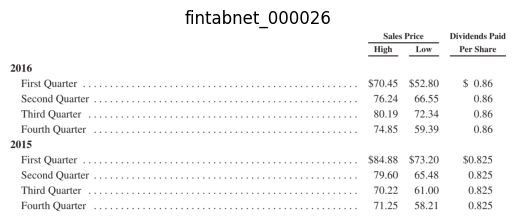

In [ ]:
# check one of the parsing results
imgid = parsed_tables[3]["imgid"]
df = parsed_tables[3]["df"]

print("imgid:", imgid)
display(df)


# display original image
IMAGE_DIR = "/content/drive/MyDrive/cv project/hierarchical_tables_v1/data/processed/images"

img_path = os.path.join(IMAGE_DIR, imgid + ".png")
print("Image path:", img_path)
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.title(imgid)
plt.show()

In [ ]:
# # save 1 sample result
# output_path = os.path.join(base_path, "parsed_sample.csv")

# parsed_tables[3]["df"].to_csv(output_path, index=False)

# print("Saved to:", output_path)

Saved to: /content/drive/MyDrive/cv project/parsed_sample.csv


In [ ]:
# save 10 sample result
import os
import shutil

# base path
base_path = "/content/drive/MyDrive/cv project/week2 parsed samples results"
os.makedirs(base_path, exist_ok=True)

IMAGE_DIR = "/content/drive/MyDrive/cv project/hierarchical_tables_v1/data/processed/images"

# save first 10 samples
for i, item in enumerate(parsed_tables[:10]):
    imgid = item["imgid"]
    df = item["df"]

    # Create a subfolder (named "imgid")
    sample_dir = os.path.join(base_path, imgid)
    os.makedirs(sample_dir, exist_ok=True)

    # save df table
    csv_path = os.path.join(sample_dir, f"{imgid}_table.csv")
    df.to_csv(csv_path, index=False)

    # save original image
    src_img_path = os.path.join(IMAGE_DIR, imgid + ".png")
    dst_img_path = os.path.join(sample_dir, f"{imgid}.png")

    try:
        shutil.copy(src_img_path, dst_img_path)
    except Exception as e:
        print(f"⚠️ Image copy failed for {imgid}: {e}")

print("✅ All samples saved to:", base_path)

✅ All samples saved to: /content/drive/MyDrive/cv project/parsed_samples


In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/cv project/week2_html parsing function.ipynb"
# Convert to HTML

[NbConvertApp] Converting notebook /content/drive/MyDrive/cv project/week2_html parsing function.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 720044 bytes to /content/drive/MyDrive/cv project/week2_html parsing function.html
